<a href="https://colab.research.google.com/github/MartinsOluwatobi/CV-Learning-Journal-/blob/main/Weight_and_Bias_using_WandB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
from torchvision import datasets, transforms
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import models
from tqdm import tqdm

In [4]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: martinsmichael (martinsmichael-nil) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Data Collection from Kaggle


In [5]:
import kagglehub
path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")


100%|██████████| 66.7M/66.7M [00:00<00:00, 132MB/s]

Extracting files...


In [6]:
'''Check if the folder-file and filenaming system suits ImageFolder
  ImageFolder expects filename in /root/class/img format'''
for root,dir,files in os.walk(path):
  for file in files:
      if file.lower().endswith(('.jpeg','.png','.jpg')):
         print(str(root))
         print(file)
         break

/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/4
Four_full (270).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/6
Six_full (2039).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/9
Nine_full (1346).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/3
Three_full (2021).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0
Zero_full (2156).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/1
One_full (1433).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/2
Two_full (637).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/7
Seven_full (1373).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/5
Five_full (1883).jpg
/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0

In [7]:
# Resize images to 3x64x64 (CxHxW) >> convert to tensor >> Augment the dataset by rotating 30% of the total dataset by 30 degrees
transform = transforms.Compose([transforms.Resize((64,64)),
                                transforms.ToTensor(),
                                transforms.RandomApply([transforms.RandomRotation(30)], p=0.3)])
data  = datasets.ImageFolder(path, transform = transform)
num_class = len(data.classes)



In [8]:
data.classes

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

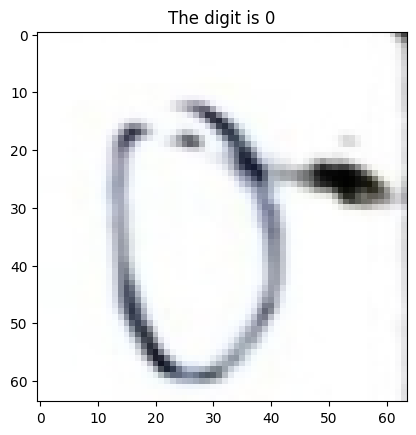

In [9]:
#Visualize image sample
sample_image, label = next(iter(data))
sample_image = sample_image.permute(1,2,0)
plt.imshow(sample_image)
plt.title(f'The digit is {label}')
plt.show()

In [10]:
# Build Class for Custom Dataset
class DigitDataset(Dataset):
  def __init__ (self,data):
    self.data = data

  def __len__ (self):
    return len(self.data)

  def __getitem__(self, idx):
      img, label = self.data[idx]
      return img, label

In [11]:
#Split data into train and test data
train_data, test_data = train_test_split(data, test_size= 0.2, random_state = 42, shuffle = True)
train_data = DigitDataset(train_data)
test_data = DigitDataset(test_data)

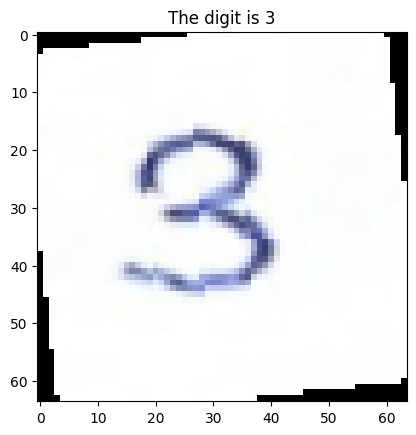

In [12]:
# Vizualise a sample data after data augmentation
image_1,label_1 = test_data[0]
image_1 = image_1.permute(1,2,0)
plt.imshow(image_1)
plt.title(f'The digit is {label_1}')
plt.show()

In [13]:
class DigitClassifier(nn.Module):
  def __init__(self, num_class):
    super().__init__()
    self.conv = nn.Sequential(
                              nn.Conv2d(in_channels =3,
                                        out_channels = 32,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(32),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =32,
                                        out_channels = 64,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(64),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =64,
                                        out_channels = 128,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(128),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =128,
                                        out_channels = 128,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(128),
                              nn.ReLU()
    )
    self.linear = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 8 * 8,1024),
        nn.ReLU(),
        nn.Linear(1024,512),
        nn.ReLU(),
        nn.Linear(512,num_class)
    )

  def forward(self,x):
    x = self.conv(x)
    x= self.linear(x)
    return x



In [14]:
def Accuracy (pred, label):
  pred = torch.argmax(pred, dim =1)
  score = (pred == label).sum().item()
  score /= len(label)
  return score

def train (model, train_dataloader, test_dataloader, optimizer, loss_fn,device):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    for image, label in train_dataloader:
        image = image.to(device)
        label = label.to(device)
        pred = model(image)
        loss = loss_fn(pred,label)
        accuracy = Accuracy(pred,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_accuracy += accuracy
    epoch_loss /= len(train_dataloader)
    epoch_accuracy /= len(train_dataloader)

    model.eval()
    with torch.no_grad():
          epoch_test_loss = 0
          epoch_test_accuracy = 0
          for test_image, test_label in test_dataloader:
              test_image = test_image.to(device)
              test_label = test_label.to(device)
              pred_test = model(test_image)
              test_loss = loss_fn(pred_test, test_label)
              test_accuracy = Accuracy(pred_test, test_label)
              epoch_test_loss += test_loss.item()
              epoch_test_accuracy += test_accuracy
          epoch_test_loss /= len(test_dataloader)
          epoch_test_accuracy /= len(test_dataloader)
    metrics = {'train_loss' : epoch_loss,
               'train_accuracy': epoch_accuracy,
               'test_loss' : epoch_test_loss,
               'test_accuracy': epoch_test_accuracy}
    wandb.log(metrics)
    return epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy


    print(f'Epoch {epoch} info')
    print('-'*50)
    print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
    print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')



In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
wandb.init( project = 'Digit-Classifier',
           config ={
    'batch_size' : 32,
    'epochs' : 10,
    'learning_rate' : 0.001,
})

train_dataloader = DataLoader(train_data,
                              batch_size = wandb.config.batch_size,
                              shuffle = True
                              )
test_dataloader = DataLoader(test_data,
                             batch_size = wandb.config.batch_size)

model = DigitClassifier(num_class= 10).to(device)
optimizer = torch.optim.SGD(model.parameters(),
                            lr = wandb.config.learning_rate)
loss_fn = nn.CrossEntropyLoss()


for epoch in tqdm(range(wandb.config.epochs)):
    epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device)
    print('-'*50)
    print(f'Epoch {epoch} info')
    print('-'*50)
    print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
    print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')
wandb.finish()


 10%|█         | 1/10 [00:04<00:37,  4.16s/it]

--------------------------------------------------
Epoch 0 info
--------------------------------------------------
Train loss : 2.24149903561056 | Test loss : 2.162906863954332
Train accuracy : 0.3078120858733103 | Test accuracy : 0.43275966183574877


 20%|██        | 2/10 [00:06<00:26,  3.37s/it]

--------------------------------------------------
Epoch 1 info
--------------------------------------------------
Train loss : 2.0031978360797127 | Test loss : 1.8061445977952746
Train accuracy : 0.4954611714815797 | Test accuracy : 0.5362721417069243


 30%|███       | 3/10 [00:09<00:21,  3.12s/it]

...

 90%|█████████ | 9/10 [00:26<00:02,  2.86s/it]

--------------------------------------------------
Epoch 8 info
--------------------------------------------------
Train loss : 0.36669078596447746 | Test loss : 0.35063750594854354
Train accuracy : 0.8978680758017492 | Test accuracy : 0.9070450885668276


100%|██████████| 10/10 [00:29<00:00,  2.97s/it]

--------------------------------------------------
Epoch 9 info
--------------------------------------------------
Train loss : 0.3191723366698219 | Test loss : 0.3147783433949506
Train accuracy : 0.9118572753776836 | Test accuracy : 0.9117652979066022


test_accuracy,▁▃▅▆▆▇▇███
test_loss,█▇▅▃▂▂▂▁▁▁
train_accuracy,▁▃▄▆▆▇▇███
train_loss,█▇▅▄▃▂▂▁▁▁
test_accuracy,0.91177
test_loss,0.31478
train_accuracy,0.91186
train_loss,0.31917


In [16]:
batch_size = [8,16,32]
learning_rate = [0.01,0.001,0.0001]
epochs_list = [10,15,20]
for batch in batch_size:
    for lr in learning_rate:
        for epoch in epochs_list:
            wandb.init(
                project = 'Digit-Classifier',
                name = f'batch_{batch}_lr_{lr}_epoch_{epoch}',
                 config= {
                'batch_size' : batch,
                'epochs' : epoch,
                'learning_rate' : lr,
            })
            train_dataloader = DataLoader(train_data,
                                          batch_size = wandb.config.batch_size,
                                          shuffle= True)
            test_dataloader = DataLoader(test_data,
                                         batch_size = wandb.config.batch_size)
            model = DigitClassifier(num_class).to(device)
            optimizer = torch.optim.SGD(model.parameters(),
                                        lr = wandb.config.learning_rate)
            loss_fn = nn.CrossEntropyLoss()
            for epoch in tqdm(range(wandb.config.epochs)):
                epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device)
                if epoch % 5 == 0:
                   print('-'*50)
                   print(f'Model training info at hyperparam: Batch_size {wandb.config.batch_size}, learning rate : {wandb.config.learning_rate}, and epochs : {wandb.config.epochs}')
                   print('-'*50)
                   print(f'Epoch {epoch} info')
                   print('-'*50)
                   print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
                   print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')
            model_path = f'Model_batch_{batch}_lr_{lr}_epoch_{epoch}.pth'
            torch.save(model.state_dict(), model_path)
            artifact = wandb.Artifact(model_path, type='model')
            artifact.add_file(model_path)
            wandb.run.log_artifact(artifact)
wandb.finish()




 10%|█         | 1/10 [00:09<01:25,  9.50s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.01, and epochs : 10
--------------------------------------------------
Epoch 0 info
--------------------------------------------------
Train loss : 0.5955937275748764 | Test loss : 0.3090711344346224
Train accuracy : 0.8060644712430427 | Test accuracy : 0.9032600053008216


 60%|██████    | 6/10 [00:55<00:37,  9.28s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.01, and epochs : 10
--------------------------------------------------
Epoch 5 info
--------------------------------------------------
Train loss : 0.019462503799057066 | Test loss : 0.0746165292687729
Train accuracy : 0.993680426716141 | Test accuracy : 0.9777365491651205


100%|██████████| 10/10 [01:32<00:00,  9.30s/it]


...

--------------------------------------------------
Model training info at hyperparam: Batch_size 32, learning rate : 0.0001, and epochs : 20
--------------------------------------------------
Epoch 10 info
--------------------------------------------------
Train loss : 2.196544867057305 | Test loss : 2.1955452654096814
Train accuracy : 0.3754555393586006 | Test accuracy : 0.36557971014492757


 80%|████████  | 16/20 [00:45<00:11,  2.85s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 32, learning rate : 0.0001, and epochs : 20
--------------------------------------------------
Epoch 15 info
--------------------------------------------------
Train loss : 2.093722003731524 | Test loss : 2.08817135669567
Train accuracy : 0.4422293267956533 | Test accuracy : 0.4381743156199678


100%|██████████| 20/20 [00:57<00:00,  2.85s/it]


test_accuracy,▁▁▂▃▄▄▅▅▅▅▆▆▆▇▇▇▇███
test_loss,███▇▇▇▇▇▆▆▆▅▅▅▄▄▃▂▂▁
train_accuracy,▁▁▂▃▄▄▅▅▅▆▆▆▇▇▇▇▇███
train_loss,███▇▇▇▇▇▆▆▆▅▅▅▄▄▃▂▂▁
test_accuracy,0.48544
test_loss,1.96362
train_accuracy,0.49029
train_loss,1.97004


In [19]:
sweep_config = {
    'method' : 'grid',
    'metric' : {
        'name' : 'test_accuracy',
        'goal' : 'maximize'
    },
    'parameters' : {
        'batch_size' : {'values' : [8,16,32]},
        'learning_rate' : {'values' : [0.01,0.001]},
        'epochs' : {'values' : [10,15,20]}
    }
}
sweep_id = wandb.sweep(sweep_config, project = 'Digit-Classifier')

def train_sweep():
    with wandb.init() as run:
        config = wandb.config

        train_dataloader = DataLoader(train_data, batch_size=config.batch_size, shuffle=True)
        test_dataloader = DataLoader(test_data, batch_size=config.batch_size)

        # Initialize model & optimizer
        model = DigitClassifier(num_class).to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=config.learning_rate)
        loss_fn = nn.CrossEntropyLoss()

        # Training Loop
        for epoch in range(config.epochs):
            train_loss, test_loss, train_acc, test_acc = train(
                model, train_dataloader, test_dataloader, optimizer, loss_fn, device
            )

            # 5. Log metrics to W&B
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "test_loss": test_loss,
                "train_acc": train_acc,
                "test_acc": test_acc
            })

wandb.agent(sweep_id, train_sweep)


Create sweep with ID: uwjzd82n
Sweep URL: https://wandb.ai/martinsmichael-nil/Digit-Classifier/sweeps/uwjzd82n


wandb: Agent Starting Run: aq5ow06a with config:
wandb: 	batch_size: 8
wandb: 	epochs: 10
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▆▇▇██▁████
test_accuracy,▆▇▇██▁████
test_loss,▃▃▂▂▂▂▁▁▁▁██▁▁▁▁▁▁▁▁
train_acc,▁▆▇▇██████
train_accuracy,▁▆▇▇██████
train_loss,██▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,9
test_acc,0.98678
test_accuracy,0.98678
test_loss,0.0575


wandb: Agent Starting Run: kd6n9i0p with config:
wandb: 	batch_size: 8
wandb: 	epochs: 10
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▅▇▇██████
test_accuracy,▁▅▇▇██████
test_loss,██▄▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▅▇▇██████
train_accuracy,▁▅▇▇██████
train_loss,██▄▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,9
test_acc,0.96753
test_accuracy,0.96753
test_loss,0.11096


...

wandb: Agent Starting Run: hd8vhl9v with config:
wandb: 	batch_size: 32
wandb: 	epochs: 20
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▂▆▁▄▇▆▇█▆███████████
test_accuracy,▂▆▁▄▇▆▇█▆███████████
test_loss,▆▆▃▃██▄▄▂▂▃▃▂▂▁▁▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▆▇▇████████████████
train_accuracy,▁▆▇▇████████████████
train_loss,██▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,19
test_acc,0.98223
test_accuracy,0.98223
test_loss,0.07323


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: wmkyiv1g with config:
wandb: 	batch_size: 32
wandb: 	epochs: 20
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▁▂▄▅▆▇▇▇▇███████████
test_accuracy,▁▂▄▅▆▇▇▇▇███████████
test_loss,██▇▇▅▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▆▆▇▇▇▇██████████
train_accuracy,▁▃▄▅▆▆▇▇▇▇██████████
train_loss,██▇▇▆▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,19
test_acc,0.95593
test_accuracy,0.95593
test_loss,0.15483


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.
